In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import rasterio
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Training hyperparameters (easy to modify)
BATCH_SIZE = 8
NUM_WORKERS = 2
LR = 1e-4
NUM_EPOCHS = 60
EARLY_STOPPING_PATIENCE = 10  # set to None to disable
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
DATASET_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")

IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

print("Images:", IMAGES_DIR)
print("Labels:", LABELS_DIR)

Images: /content/drive/MyDrive/Cellula/WaterSegmentation/data/images
Labels: /content/drive/MyDrive/Cellula/WaterSegmentation/data/labels


In [6]:
NUM_CHANNELS = 12

NORM_CHANNELS = [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]

EXCLUDE_FROM_NORM = [7, 10]  # QA Band, WorldCover

assert len(NORM_CHANNELS) + len(EXCLUDE_FROM_NORM) == NUM_CHANNELS

print("Channels to normalize:", NORM_CHANNELS)
print("Channels excluded from normalization:", EXCLUDE_FROM_NORM)

Channels to normalize: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11]
Channels excluded from normalization: [7, 10]


In [7]:
pairs = []

for image_path in sorted(IMAGES_DIR.glob("*.tif")):

    label_path = LABELS_DIR / f"{image_path.stem}.png"

    if label_path.exists():
        pairs.append((image_path, label_path))

print("Total image-mask pairs:", len(pairs))

Total image-mask pairs: 306


In [8]:
def has_water(label_path):
    with rasterio.open(label_path) as src:
        mask = src.read(1)
    return int(np.any(mask == 1))

strat_labels = np.array([has_water(lbl) for _, lbl in pairs])
print("Images with water:", int(np.sum(strat_labels == 1)))
print("Images without water:", int(np.sum(strat_labels == 0)))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Images with water: 261
Images without water: 45


In [9]:
total_water = 0
total_bg = 0
for _, lbl in pairs:
    with rasterio.open(lbl) as src:
        m = src.read(1)
    total_water += int((m == 1).sum())
    total_bg += int((m == 0).sum())

total_px = total_water + total_bg
print(f"\nWater pixels: {total_water} ({total_water/total_px*100:.2f}%)")
print(f"Background:   {total_bg} ({total_bg/total_px*100:.2f}%)")
print(f"Suggested pos_weight: {total_bg / max(total_water, 1):.4f}")


Water pixels: 1302272 (25.98%)
Background:   3711232 (74.02%)
Suggested pos_weight: 2.8498


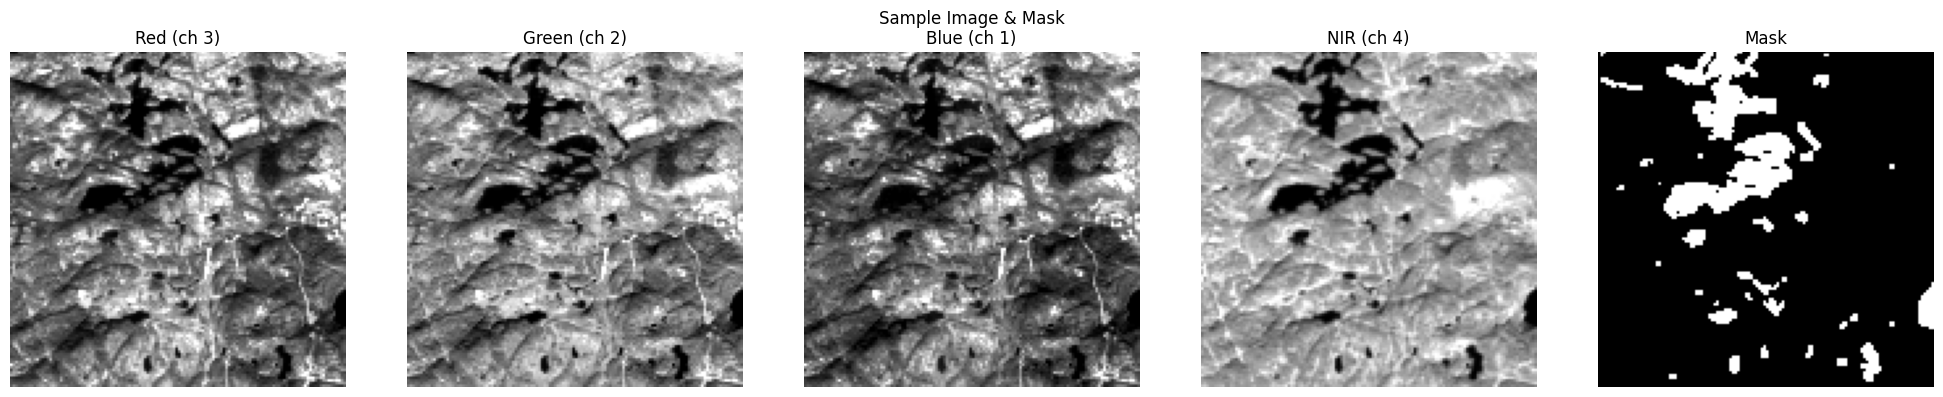

In [10]:
# Visualize a sample image (RGB + NIR) and its mask
img_path, msk_path = pairs[0]
with rasterio.open(img_path) as src:
    img_raw = src.read().astype(np.float32)
with rasterio.open(msk_path) as src:
    msk_raw = src.read(1)

show_channels = [3, 2, 1, 4]
names = ["Red (ch 3)", "Green (ch 2)", "Blue (ch 1)", "NIR (ch 4)"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, ch, name in zip(axes[:4], show_channels, names):
    band = img_raw[ch]
    vmin, vmax = np.percentile(band, (2, 98))
    ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(name)
    ax.axis("off")
axes[4].imshow(msk_raw, cmap="gray")
axes[4].set_title("Mask")
axes[4].axis("off")
plt.suptitle("Sample Image & Mask")
plt.tight_layout()
plt.show()

In [11]:
train_pairs, temp_pairs, train_labels, temp_labels = train_test_split(
    pairs, strat_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=strat_labels
)
val_pairs, test_pairs, val_labels, test_labels = train_test_split(
    temp_pairs, temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print(f"Train: {len(train_pairs)}  (water: {int(train_labels.sum())})")
print(f"Val:   {len(val_pairs)}  (water: {int(val_labels.sum())})")
print(f"Test:  {len(test_pairs)}  (water: {int(test_labels.sum())})")

Train: 214  (water: 183)
Val:   46  (water: 39)
Test:  46  (water: 39)


In [12]:
def compute_channel_stats(pairs, norm_channels):
    n_ch = len(norm_channels)
    sums = np.zeros(n_ch, dtype=np.float64)
    sums_sq = np.zeros(n_ch, dtype=np.float64)
    n_pixels = 0

    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)  # (12, H, W)
        img_norm = img[norm_channels]
        img_norm = np.nan_to_num(img_norm, nan=0.0, posinf=0.0, neginf=0.0)
        flat = img_norm.reshape(n_ch, -1)
        sums += flat.sum(axis=1)
        sums_sq += (flat ** 2).sum(axis=1)
        n_pixels += flat.shape[1]

    mean = sums / n_pixels
    var = sums_sq / n_pixels - mean ** 2
    var = np.clip(var, 1e-12, None)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)

train_mean, train_std = compute_channel_stats(train_pairs, NORM_CHANNELS)
print("Train Mean (10 channels):\n", train_mean)
print("\nTrain Std (10 channels):\n", train_std)

# Save stats (small JSON only, no image copies)
stats = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "norm_channels": NORM_CHANNELS,
    "exclude_from_norm": EXCLUDE_FROM_NORM,
    "num_channels": NUM_CHANNELS,
}
with open(DATASET_DIR / "train_channel_stats.json", "w") as f:
    json.dump(stats, f, indent=4)
print("\nSaved:", DATASET_DIR / "train_channel_stats.json")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Train Mean (10 channels):
 [ 394.15018   492.13864   820.9418    973.08264  2069.7773   1948.11
 1336.509     123.91796   294.36536    10.063989]

Train Std (10 channels):
 [ 261.87573   310.67526   396.09274   567.03094  1070.1465   1196.9388
  953.8549   1394.3047    456.21017    28.180136]

Saved: /content/drive/MyDrive/Cellula/WaterSegmentation/data/train_channel_stats.json


In [13]:
class WaterSegDataset(Dataset):
    def __init__(self, pairs, mean, std,
                 norm_channels=NORM_CHANNELS,
                 augment=False):
        super().__init__()
        self.pairs = pairs
        self.norm_channels = list(norm_channels)
        self.augment = augment
        # (10, 1, 1) for broadcasting against (10, H, W)
        self.mean = torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(-1, 1, 1)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32)  # (12, H, W)
        image = torch.from_numpy(image)

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)  # (1, H, W)

        # --- Normalization (only on NORM_CHANNELS) ---
        image_norm = image[self.norm_channels]
        image_norm = (image_norm - self.mean) / self.std
        image_out = image.clone()
        image_out[self.norm_channels] = image_norm

        # --- Augmentation (train only) ---
        if self.augment:
            # Flips (الموجودين أصلاً)
            if torch.rand(1).item() > 0.5:
                image_out = torch.flip(image_out, dims=[2]).clone()
                mask = torch.flip(mask, dims=[2]).clone()
            if torch.rand(1).item() > 0.5:
                image_out = torch.flip(image_out, dims=[1]).clone()
                mask = torch.flip(mask, dims=[1]).clone()

            # إضافة Rotations 90 درجة
            if torch.rand(1).item() > 0.5:
                image_out = torch.rot90(image_out, k=1, dims=[1, 2]).clone()
                mask = torch.rot90(mask, k=1, dims=[1, 2]).clone()

            # إضافة تغييرات بسيطة في القيم الطيفية (Noise خفيف للـ Normalized Channels فقط)
            if torch.rand(1).item() > 0.5:
                noise = torch.randn_like(image_out[self.norm_channels]) * 0.05
                image_out[self.norm_channels] += noise

        return image_out, mask


train_ds = WaterSegDataset(train_pairs, train_mean, train_std, augment=True)
val_ds   = WaterSegDataset(val_pairs,   train_mean, train_std, augment=False)
test_ds  = WaterSegDataset(test_pairs,  train_mean, train_std, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))

# Sanity check
images, masks = next(iter(train_loader))
print("\nImages shape:", images.shape, "| dtype:", images.dtype)
print("Masks shape: ", masks.shape,  "| dtype:", masks.dtype)
print("Unique mask values:", torch.unique(masks))

Train batches: 27
Val batches:   6
Test batches:  6

Images shape: torch.Size([8, 12, 128, 128]) | dtype: torch.float32
Masks shape:  torch.Size([8, 1, 128, 128]) | dtype: torch.float32
Unique mask values: tensor([0., 1.])


In [14]:
class UNet(nn.Module):
    """U-Net for 12-channel input, 1-channel binary segmentation output."""
    def __init__(self, in_ch=12, out_ch=1, base_f=8, depth=6):
        super().__init__()

        def conv_block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc),
                nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1, bias=False),
                nn.BatchNorm2d(oc),
                nn.ReLU(inplace=True),
            )

        self.encoders = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()

        f = base_f
        c_in = in_ch
        for _ in range(depth):
            self.encoders.append(conv_block(c_in, f))
            c_in = f
            f *= 2

        self.bottleneck = conv_block(c_in, f)

        for _ in range(depth):
            self.upconvs.append(nn.ConvTranspose2d(f, f // 2, 2, stride=2))
            self.decoders.append(conv_block(f, f // 2))
            f //= 2

        self.final = nn.Conv2d(f, out_ch, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)
        return self.final(x)


model = UNet(in_ch=NUM_CHANNELS, out_ch=1, base_f=8, depth=6).to(DEVICE)
print("Model parameters:", sum(p.numel() for p in model.parameters()))

# Quick shape sanity check
with torch.no_grad():
    y = model(torch.randn(2, 12, 128, 128).to(DEVICE))
print("Output shape:", y.shape)  # expect (2, 1, 128, 128)

Model parameters: 7783073
Output shape: torch.Size([2, 1, 128, 128])


In [15]:
# ==============================================================================
# Section 8: Training
# ==============================================================================
@torch.no_grad()
def compute_metrics(logits, targets, thr=0.5, eps=1e-7):
    """Compute Water-class metrics with safe division."""
    preds = (torch.sigmoid(logits) > thr).float().view(-1)
    targets = targets.view(-1)

    tp = ((preds == 1) & (targets == 1)).sum().item()
    fp = ((preds == 1) & (targets == 0)).sum().item()
    fn = ((preds == 0) & (targets == 1)).sum().item()
    tn = ((preds == 0) & (targets == 0)).sum().item()

    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)
    accuracy  = (tp + tn) / (tp + tn + fp + fn + eps)
    return {"iou": iou, "precision": precision, "recall": recall,
            "f1": f1, "accuracy": accuracy}


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss, logits_all, targets_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        logits_all.append(logits.detach().cpu())
        targets_all.append(y.detach().cpu())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(torch.cat(logits_all), torch.cat(targets_all))
    return avg_loss, metrics


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss, logits_all, targets_all = 0.0, [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        logits_all.append(logits.cpu())
        targets_all.append(y.cpu())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_metrics(torch.cat(logits_all), torch.cat(targets_all))
    return avg_loss, metrics


# --- Optimizer & Loss ---
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.BCEWithLogitsLoss()

# --- Training loop ---
best_val_iou = 0.0
best_path = "/content/best_unet.pt"
epochs_no_improve = 0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_m = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    vl_loss, vl_m = evaluate(model, val_loader, loss_fn, DEVICE)

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": vl_loss, **vl_m})

    print(f"Epoch {epoch:02d} | "
          f"Train Loss {tr_loss:.4f} | "
          f"Val Loss {vl_loss:.4f} | "
          f"IoU {vl_m['iou']:.4f} | "
          f"F1 {vl_m['f1']:.4f} | "
          f"Prec {vl_m['precision']:.4f} | "
          f"Rec {vl_m['recall']:.4f}")

    # Save best on Validation IoU
    if vl_m["iou"] > best_val_iou:
        best_val_iou = vl_m["iou"]
        torch.save(model.state_dict(), best_path)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Early stopping
    if EARLY_STOPPING_PATIENCE is not None and epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
        break

print(f"\nBest Validation IoU: {best_val_iou:.4f}")
print(f"Best model saved to: {best_path}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 01 | Train Loss 0.6942 | Val Loss 0.6828 | IoU 0.2712 | F1 0.4267 | Prec 0.3172 | Rec 0.6516


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 02 | Train Loss 0.6657 | Val Loss 0.6552 | IoU 0.3086 | F1 0.4716 | Prec 0.3693 | Rec 0.6524


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

...

Epoch 50 | Train Loss 0.3738 | Val Loss 0.3489 | IoU 0.6119 | F1 0.7592 | Prec 0.8765 | Rec 0.6697


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 51 | Train Loss 0.3494 | Val Loss 0.3501 | IoU 0.6160 | F1 0.7624 | Prec 0.9018 | Rec 0.6603


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 52 | Train Loss 0.3505 | Val Loss 0.3498 | IoU 0.5623 | F1 0.7198 | Prec 0.9513 | Rec 0.5789

Early stopping at epoch 52 (no improvement for 10 epochs).

Best Validation IoU: 0.6176
Best model saved to: /content/best_unet.pt


In [16]:
# ==============================================================================
# Section 9: Test Evaluation (best model only, evaluated once)
# ==============================================================================
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

test_loss, test_m = evaluate(model, test_loader, loss_fn, DEVICE)

results_df = pd.DataFrame([{
    "Split": "Test",
    "Loss": round(test_loss, 4),
    "Accuracy": round(test_m["accuracy"], 4),
    "Precision": round(test_m["precision"], 4),
    "Recall": round(test_m["recall"], 4),
    "F1": round(test_m["f1"], 4),
    "IoU": round(test_m["iou"], 4),
}])
print("=== Test Results ===")
print(results_df.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


=== Test Results ===
Split   Loss  Accuracy  Precision  Recall     F1    IoU
 Test 0.3642    0.9117     0.8428  0.7365 0.7861 0.6475


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


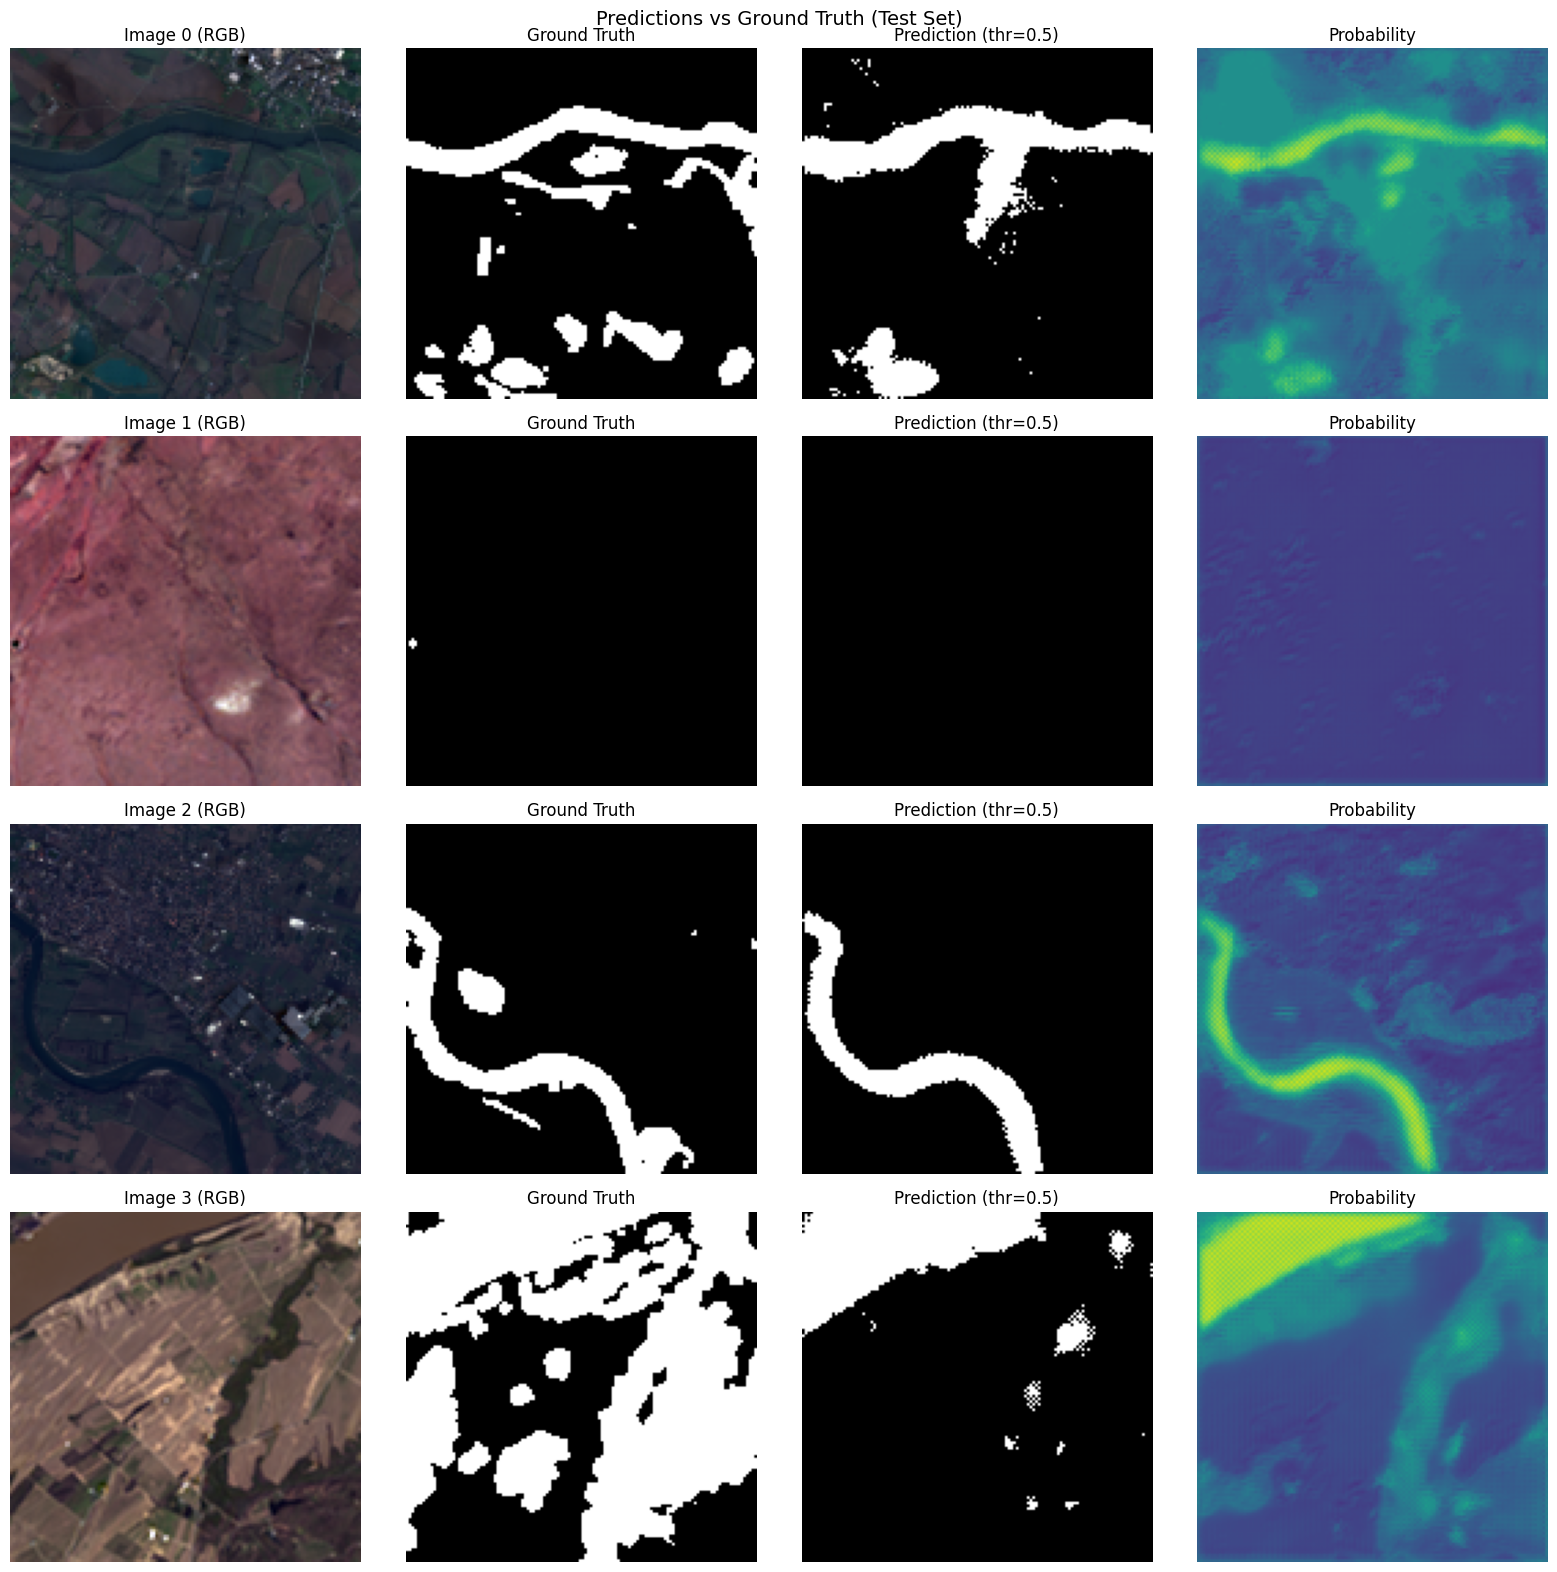

In [17]:
# ==============================================================================
# Section 10: Prediction Visualization
# ==============================================================================
@torch.no_grad()
def predict_batch(model, loader, n=3):
    model.eval()
    x, y = next(iter(loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    logits = model(x)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    return x.cpu(), y.cpu(), preds.cpu(), probs.cpu()

x_vis, y_vis, p_vis, prob_vis = predict_batch(model, test_loader, n=4)

n_show = min(4, x_vis.size(0))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4 * n_show))
if n_show == 1:
    axes = axes[None, :]

for i in range(n_show):
    # RGB composite (Red=ch3, Green=ch2, Blue=ch1) using min-max per band
    rgb = x_vis[i, [3, 2, 1]].numpy()
    rgb = np.stack([(b - b.min()) / (b.max() - b.min() + 1e-8) for b in rgb], axis=-1)

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Image {i} (RGB)")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_vis[i, 0], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(p_vis[i, 0], cmap="gray")
    axes[i, 2].set_title("Prediction (thr=0.5)")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(prob_vis[i, 0], cmap="viridis", vmin=0, vmax=1)
    axes[i, 3].set_title("Probability")
    axes[i, 3].axis("off")

plt.suptitle("Predictions vs Ground Truth (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()